<a href="https://colab.research.google.com/github/peremartra/Rearchitecting-LLMs/blob/main/CH08/CH08_NB01_T4_KVCache_HuggingFace.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table style="width:100%; border:none; background:none;">
  <tr style="border:none;">
    <td style="border:none; vertical-align:middle; text-align:left; width: 120px;">
      <a href="https://hubs.la/Q040tvsK0"><img src="https://raw.githubusercontent.com/peremartra/Rearchitecting-LLMs/main/Images/cover.png" width="100px" style="border-radius: 4px;"></a>
    </td>
    <td style="border:none; vertical-align:middle; text-align:left;">
      <p style="margin: 0; font-size: 14px;">
        Supplementary code for the <a href="https://hubs.la/Q040tvsK0">Rearchitecting LLMs</a> book by <a href="https://github.com/peremartra">Pere Martra</a>.<br>
        <br>
        Code repository: <a href="https://github.com/peremartra/Rearchitecting-LLMs">https://github.com/peremartra/Rearchitecting-LLMs</a>
      </p>
    </td>
  </tr>
</table>

# Quantizing the KV Cache: Hugging Face
## Reducing the dynamic memory footprint during inference

[![LinkedIn](https://img.shields.io/badge/LinkedIn-0077B5?style=flat&logo=linkedin&logoColor=white)](https://www.linkedin.com/in/pere-martra/) [![GitHub](https://img.shields.io/badge/GitHub-100000?style=flat&logo=github&logoColor=white)](https://github.com/peremartra) [![X](https://img.shields.io/badge/X-000000?style=flat&logo=x&logoColor=white)](https://x.com/PereMartra) [![Hugging Face](https://img.shields.io/badge/🤗%20Hugging%20Face-blue)](https://huggingface.co/oopere)

_____
* **Author:** Pere Martra
* **Models:** meta-llama/Llama-3.2-3B
* **Colab Environment:** T4 GPU (Free Tier)
* **Keys:**
  * KV Cache
  * Quantization
  * BitsAndBytes
  * Quanto
* **References:**
  * [Manning Book: Rearchitecting LLMs](https://livebook.manning.com/book/rearchitecting-llms)
  * [Quanto Documentation](https://github.com/huggingface/optimum-quanto)
_____

This notebook compares three inference configurations to isolate the effect of KV cache quantization on VRAM usage:

1. **FP16 baseline** — model and KV cache both in FP16.
2. **4-bit weight quantization (BitsAndBytes)** — smaller static footprint, but KV cache still grows in FP16.
3. **FP16 model + 4-bit KV cache (Quanto)** — static footprint unchanged, dynamic delta reduced.

By fixing one variable at a time we can clearly see which lever — weight precision or cache precision — controls which component of the total VRAM budget.

## 1. Install dependencies

In [1]:
!pip install -q transformers==4.51.3
!pip install -q accelerate
!pip install -q bitsandbytes
!pip install -q optimum-quanto
!pip install -q lm_eval
!pip install -q optipfair
!pip install -q langdetect
!pip install -q codecarbon

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 127.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 22.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 kB 11.7 MB/s eta 0:00:00
  

## 2. Imports and configuration

In [2]:
import torch
import random
import numpy as np
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    QuantizedCacheConfig,
)
import sys
sys.path.append('..')

!wget -q https://raw.githubusercontent.com/peremartra/Rearchitecting-LLMs/main/utils.py

from utils import get_output, measure_memory_allocation

MODEL_NAME = "meta-llama/Llama-3.2-3B"

# Long prompt to make KV cache growth visible in memory measurements
PROMPT = (
    "Explain in detail the history of artificial intelligence, "
    "covering all major milestones from the 1950s to the present day."
)
MAX_NEW_TOKENS = 500

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


⚠️ Hardware note — expected output varies by GPU architecture
The numbers in the summary table depend on the GPU you are running on:

Ampere or newer (sm_80+, e.g. A100, L4): All three tests run with full CUDA acceleration. The Quanto backend compiles its CUDA extension and operates at near-native speed. Expect a throughput drop in Test 3 of roughly 5–8×  compared to the FP16 baseline.
Turing or older (sm_75, e.g. T4): The Quanto CUDA extension requires QUANTO_DISABLE_CUDA=1 to prevent a compilation failure. With this flag, Quanto falls back to a pure Python backend that quantizes and dequantizes the KV cache at every attention step entirely on the CPU side. Expect a throughput drop in Test 3 of 10× or more compared to the FP16 baseline.

In both cases the static VRAM and dynamic delta conclusions hold: weight quantization (BnB) reduces static footprint, KV cache quantization (Quanto) reduces dynamic delta. The throughput penalty of Test 3 is a backend limitation, not an inherent property of KV cache quantization — production implementations using fused CUDA kernels (e.g. FlashAttention with int8 cache) close most of this gap.

In [3]:
import os
os.environ["QUANTO_DISABLE_CUDA"] = "1"

In [4]:
def set_seed(seed=42):
    """Set random seed for reproducibility"""
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)

set_seed(42)

## 3. Load tokenizer

We load the tokenizer once and reuse it across all three tests.

In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

## 4. Test 1 — Baseline: FP16

We start with the standard FP16 load. This establishes our ceiling:
- **Static VRAM** is high because all model weights live in FP16.
- **Dynamic delta** grows proportionally with `MAX_NEW_TOKENS` because the KV cache is also FP16.

All subsequent tests will be compared against these numbers.

In [6]:
model_fp16 = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)

results_fp16 = measure_memory_allocation(
    model_fp16, tokenizer, PROMPT,
    max_new_tokens=MAX_NEW_TOKENS
)
print(results_fp16)

del model_fp16
torch.cuda.empty_cache()

config.json:   0%|          | 0.00/844 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/1.46G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:631: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:636: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(


{'static_vram_mb': 6127.84, 'dynamic_delta_mb': 112.37, 'throughput_tokens_s': 25.36}


**Expected output:** Static VRAM ~6 GB, dynamic delta proportional to `MAX_NEW_TOKENS`.

Note that quantizing model weights (next test) will shrink the static footprint but leave the KV cache allocation unchanged.

## 5. Test 2 — Full model quantization: 4-bit weights (BitsAndBytes)

Here we quantize the model weights to 4-bit using BitsAndBytes. This dramatically reduces the **static** VRAM footprint.

The key insight is that BitsAndBytes quantizes *weights*, not the KV cache. During generation, the attention mechanism still materializes keys and values in FP16, so the **dynamic delta** should be nearly identical to Test 1.

This test isolates the weight-precision lever.

In [7]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,  # Explicit to ensure comparable
)                                           # measurements across tests

model_4bit = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto"
)

results_4bit = measure_memory_allocation(
    model_4bit, tokenizer, PROMPT,
    max_new_tokens=MAX_NEW_TOKENS
)
print(results_4bit)

del model_4bit
torch.cuda.empty_cache()

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

{'static_vram_mb': 2272.06, 'dynamic_delta_mb': 104.35, 'throughput_tokens_s': 19.47}


**Expected output:** Static VRAM ~2–3 GB. Dynamic delta practically identical to Test 1 — the KV cache is still materialized in FP16.

## 6. Test 3 — KV cache quantization: 4-bit cache (Quanto)

Now we flip the lever: the model stays in FP16 (same static footprint as Test 1), but we inject a `QuantizedCacheConfig` that tells `model.generate()` to store keys and values in 4-bit via the Quanto backend.

The static VRAM should match Test 1. The dynamic delta should be significantly smaller because each KV entry now occupies 4 bits instead of 16.

A possible side-effect is a drop in throughput: quantizing and dequantizing the cache on every attention step adds CPU/GPU overhead, especially with the Python-level Quanto backend.

In [8]:
model_kvcache = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)

cache_config = QuantizedCacheConfig(
    backend="quanto",
    nbits=4
)

results_kvcache = measure_memory_allocation(
    model_kvcache, tokenizer, PROMPT,
    max_new_tokens=MAX_NEW_TOKENS,
    cache_config=cache_config,        # Injected into generate()
    cache_implementation="quantized"
)
print(results_kvcache)

del model_kvcache
torch.cuda.empty_cache()

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

{'static_vram_mb': 6135.96, 'dynamic_delta_mb': 34.86, 'throughput_tokens_s': 3.72}


**Expected output:** Static VRAM similar to Test 1. Dynamic delta significantly smaller. Throughput may decrease due to the quantization overhead applied at every generation step — this is expected and documented in the summary table below.

## 7. Results summary

The table below consolidates all three tests and makes the trade-offs explicit:

| Lever | Affects static VRAM? | Affects dynamic delta? |
|---|---|---|
| Weight quantization (BnB 4-bit) | ✅ Yes — large reduction | ❌ No |
| KV cache quantization (Quanto 4-bit) | ❌ No | ✅ Yes — large reduction |

In [9]:
import pandas as pd

summary = pd.DataFrame([
    {
        "Configuration":           "FP16 Base",
        "Static VRAM (MB)":        results_fp16["static_vram_mb"],
        "Dynamic VRAM Delta (MB)": results_fp16["dynamic_delta_mb"],
        "Throughput (Tokens/s)":   results_fp16["throughput_tokens_s"],
    },
    {
        "Configuration":           "4-bit Weights (BnB)",
        "Static VRAM (MB)":        results_4bit["static_vram_mb"],
        "Dynamic VRAM Delta (MB)": results_4bit["dynamic_delta_mb"],
        "Throughput (Tokens/s)":   results_4bit["throughput_tokens_s"],
    },
    {
        "Configuration":           "FP16 + 4-bit KV Cache",
        "Static VRAM (MB)":        results_kvcache["static_vram_mb"],
        "Dynamic VRAM Delta (MB)": results_kvcache["dynamic_delta_mb"],
        "Throughput (Tokens/s)":   results_kvcache["throughput_tokens_s"],
    },
])

print(summary.to_string(index=False))

        Configuration  Static VRAM (MB)  Dynamic VRAM Delta (MB)  Throughput (Tokens/s)
            FP16 Base           6127.84                   112.37                  25.36
  4-bit Weights (BnB)           2272.06                   104.35                  19.47
FP16 + 4-bit KV Cache           6135.96                    34.86                   3.72


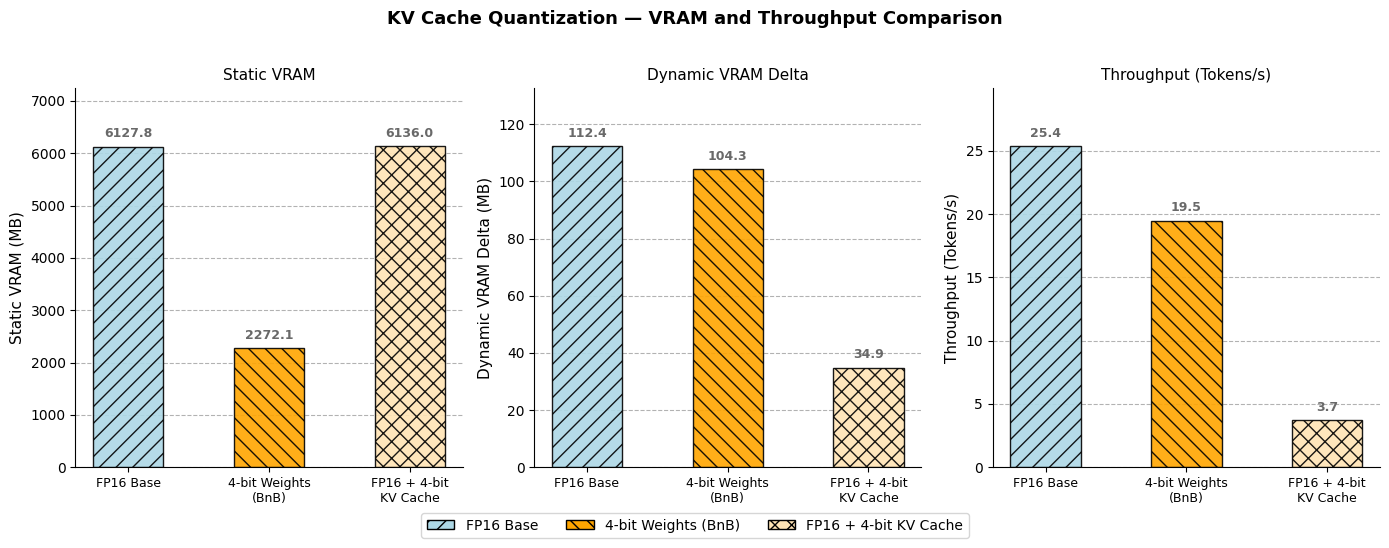

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data ---
configurations = ['FP16 Base', '4-bit Weights\n(BnB)', 'FP16 + 4-bit\nKV Cache']

static_vram  = [results_fp16["static_vram_mb"],    results_4bit["static_vram_mb"],    results_kvcache["static_vram_mb"]]
dynamic_vram = [results_fp16["dynamic_delta_mb"],   results_4bit["dynamic_delta_mb"],   results_kvcache["dynamic_delta_mb"]]
throughput   = [results_fp16["throughput_tokens_s"], results_4bit["throughput_tokens_s"], results_kvcache["throughput_tokens_s"]]

colors  = ['lightblue', 'orange', 'moccasin']
hatches = ['//', '\\\\', 'xx']

x     = np.arange(len(configurations))
width = 0.5

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.patch.set_facecolor('white')

panels = [
    (axes[0], static_vram,  'Static VRAM (MB)',        'Static VRAM'),
    (axes[1], dynamic_vram, 'Dynamic VRAM Delta (MB)', 'Dynamic VRAM Delta'),
    (axes[2], throughput,   'Throughput (Tokens/s)',   'Throughput (Tokens/s)'),
]

for ax, values, ylabel, title in panels:
    ax.set_facecolor('white')
    for i, (val, color, hatch) in enumerate(zip(values, colors, hatches)):
        ax.bar(
            x[i], val, width,
            color=color, alpha=0.9,
            hatch=hatch, edgecolor='black'
        )
        ax.text(
            x[i], val + max(values) * 0.02,
            f'{val:.1f}',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='dimgray'
        )

    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(configurations, fontsize=9)
    ax.set_ylim(0, max(values) * 1.18)
    ax.yaxis.grid(True, linestyle='--', alpha=0.6, color='gray')
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

# --- Legend ---
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='lightblue', hatch='//',   edgecolor='black', label='FP16 Base'),
    Patch(facecolor='orange',    hatch='\\\\', edgecolor='black', label='4-bit Weights (BnB)'),
    Patch(facecolor='moccasin',  hatch='xx',   edgecolor='black', label='FP16 + 4-bit KV Cache'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3,
           fontsize=10, framealpha=0.8, bbox_to_anchor=(0.5, -0.05))

plt.suptitle('KV Cache Quantization — VRAM and Throughput Comparison',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('kvcache_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


The three tests isolate two independent levers for reducing VRAM consumption during inference:

Weight quantization (BnB 4-bit) produces a large reduction in static VRAM — the model footprint roughly triples in efficiency — while leaving the dynamic delta nearly unchanged. The KV cache still grows in FP16 at every generation step.
KV cache quantization (Quanto 4-bit) leaves static VRAM unchanged — the model weights are the same as the FP16 baseline — but reduces the dynamic delta by approximately 3×. Each key and value entry now occupies 4 bits instead of 16.
Throughput in the KV cache quantization test is significantly lower than the other two configurations. This reflects the overhead of the backend operating at every attention step, and should not be interpreted as an inherent cost of KV cache quantization — optimized production backends close most of this gap.

The two levers are orthogonal and can be combined: a 4-bit weight model with a 4-bit KV cache would capture both reductions simultaneously.